# Reports visualisation

In [1]:
import os
import glob
import pandas as pd
from pathlib import Path
import re

from src.definitions import REPORTS_FOLDER
from src.visualization.plot import plot_generic

## Indian Pines Binnary Classification (by datapoints count)

In [2]:
def load_reports_by_class(
    directory: Path, report_name: str, clazz: int
) -> list[tuple[int, Path]]:
    mask_arr = [
        (int(re.search(r"-(\d+)\.csv$", str(fn)).group(1)), fn)
        for fn in directory.glob(f"{report_name}__{clazz}-*.csv")
    ]

    return sorted(list(set(mask_arr)), key=lambda it: it[0])


def get_max_rows_from_csvs(directory, report_name, clazz, column_name):
    """
    Reads all CSV files with names like 'indian_pines_bin_2-{some_number}.csv'
    in the given directory. For each file, finds the row with the maximum
    value in the given column and returns:
      - a list of those rows as dictionaries
      - a list of the {some_number} parts extracted from filenames
    """
    reports = load_reports_by_class(directory, report_name, clazz)

    conts, file_paths = zip(*reports)
    counts = list(conts)
    file_paths = list(file_paths)

    max_rows = []

    for file_path in file_paths:
        # Read CSV
        df = pd.read_csv(file_path)

        if column_name not in df.columns:
            raise ValueError(f"Column '{column_name}' not found in {file_paths}")

        # Get row with max value in the given column
        max_row = df.loc[df[column_name].idxmax()].to_dict()
        max_rows.append(max_row)

    return max_rows, counts

In [3]:
directory = REPORTS_FOLDER / "runs"
name_prefix = "indian_pines"
class_id = 2
optimize_metric = "kappa"

In [4]:
metrics, counts = get_max_rows_from_csvs(directory, name_prefix, class_id, optimize_metric)

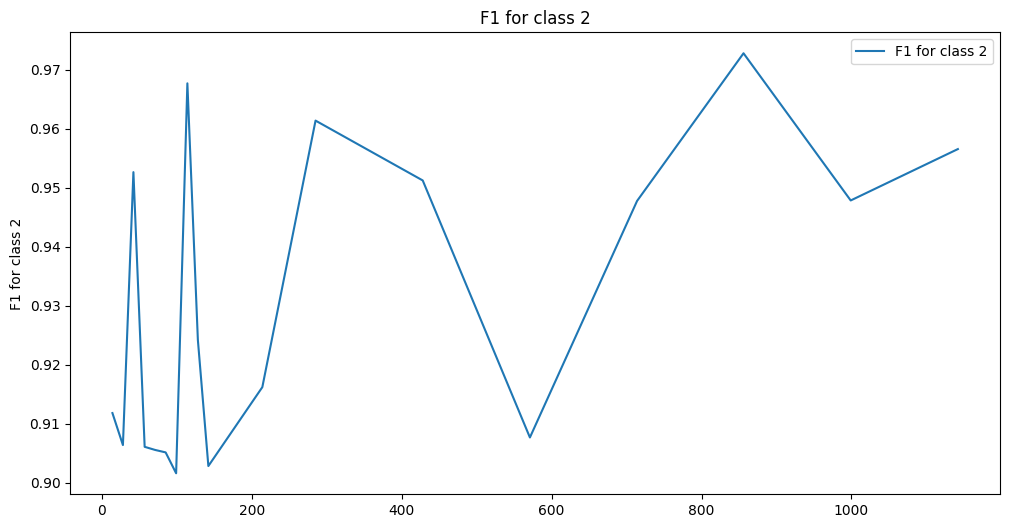

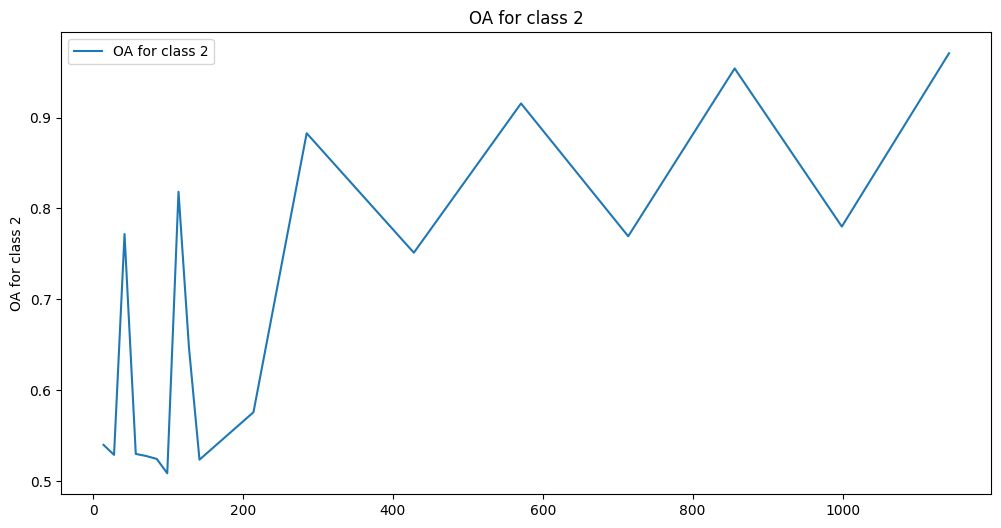

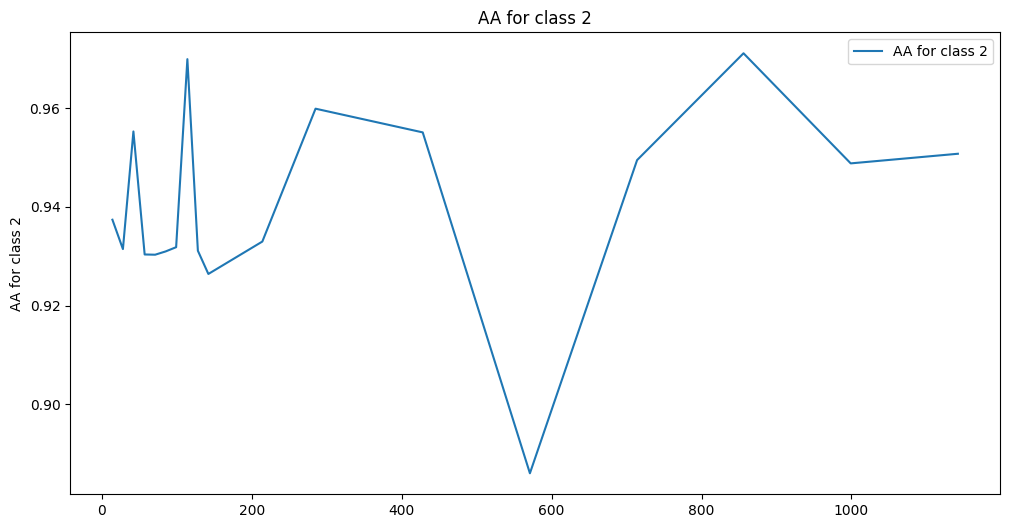

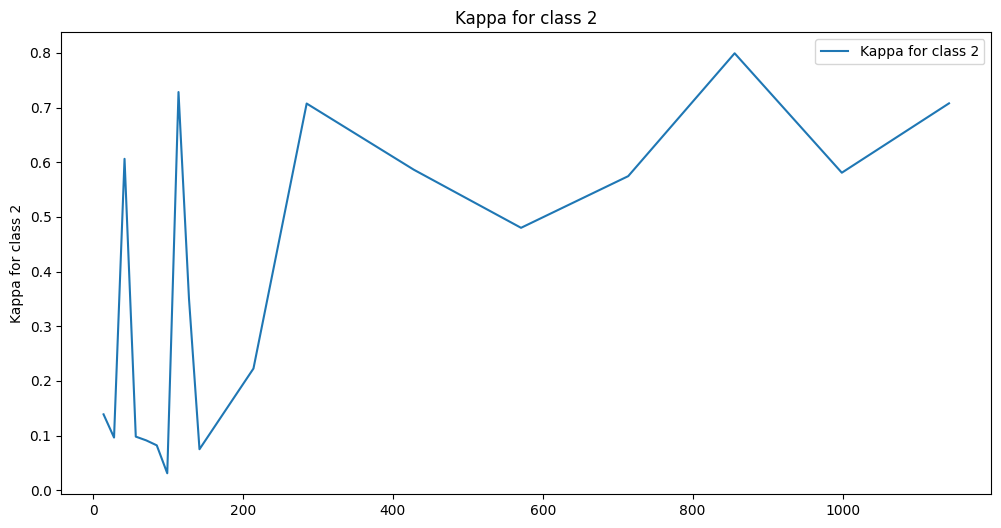

In [5]:
f1s = [it["f1"] for it in metrics]
oas = [it["OA"] for it in metrics]
aas = [it["AA"] for it in metrics]
kappas = [it["kappa"] for it in metrics]

plot_generic(counts, f1s, desc=f"F1 for class {class_id}")
plot_generic(counts, oas, desc=f"OA for class {class_id}")
plot_generic(counts, aas, desc=f"AA for class {class_id}")
plot_generic(counts, kappas, desc=f"Kappa for class {class_id}")